In [1]:
import pandas as pd

df = pd.read_json("test.json", lines=True)
df.transpose()
df["44e8d2a0-7e01-450b-90b0-beb7400d2c1e"]

0    [{'hand 1': [{'x': 0.28600000000000003, 'y': 0...
Name: 44e8d2a0-7e01-450b-90b0-beb7400d2c1e, dtype: object

In [2]:
len(df["44e8d2a0-7e01-450b-90b0-beb7400d2c1e"][0])

76

In [3]:
df = df.iloc[:, :453]
df.head()

,44e8d2a0-7e01-450b-90b0-beb7400d2c1e,df5b08f0-41d1-4572-889c-8b893e71069b,17f53df4-c467-4aff-9f48-20687b63d49a,e3add916-c708-4339-ad98-7e2740be29e9,bd7272ed-1850-48f1-a2a8-c8fed523dc37,eced728b-ec24-4f91-a967-7377542a23e6,cf6845ac-9e02-49b4-8d2b-f56c789f973a,330fc737-22a8-419b-9e46-b9af6adef8bf,a5948d20-283a-45d4-8ab3-9c63f35db522,3f0389e8-fe70-41b0-806d-8c1aae3d20c1,...,7d8bf38b-0bd5-4167-acba-45b9f0c02d80,638dd413-da62-4b44-bd2c-f828fc8cba6a,f6dce0fb-4d4a-405f-b24b-bb123f47ef55,715106a3-6028-4faa-a409-c8dca9c16c5e,cdcb451b-5668-47ae-8533-87c12669aaca,1ec613ad-f368-411c-9bae-869e124dfefc,c26440d1-a014-45fd-8a92-01278815c755,71904e06-bc17-46bb-9e22-f247bca40b11,c56947aa-0d08-4e02-bc29-09d402af7e30,25bd4d69-7e58-4239-8eb8-df0818c5fd36
0,"[{'hand 1': [{'x': 0.28600000000000003, 'y': 0...","[{'hand 1': [{'x': 0.257, 'y': 0.671, 'z': 0.0...","[{'hand 1': [{'x': 0.306, 'y': 0.559, 'z': 0.0...","[{'hand 1': [{'x': 0.255, 'y': 0.535, 'z': 0.0...","[{'hand 1': [{'x': 0.241, 'y': 0.656, 'z': 0.0...","[{'hand 1': [{'x': 0.193, 'y': 0.8240000000000...","[{'hand 1': [{'x': 0.723, 'y': 0.684, 'z': 0.0...","[{'hand 1': [{'x': 0.214, 'y': 0.634, 'z': 0.0...","[{'hand 1': [{'x': 0.30000000000000004, 'y': 0...","[{'hand 1': [{'x': 0.342, 'y': 0.72, 'z': 0.0}...",...,"[{'hand 1': [{'x': 0.763, 'y': 0.753, 'z': 0.0...","[{'hand 1': [{'x': 0.784, 'y': 0.763, 'z': 0.0...","[{'hand 1': [{'x': 0.802, 'y': 0.753, 'z': 0.0...","[{'hand 1': [{'x': 0.788, 'y': 0.762, 'z': 0.0...","[{'hand 1': [{'x': 0.755, 'y': 0.779, 'z': 0.0...","[{'hand 1': [{'x': 0.759, 'y': 0.774, 'z': 0.0...","[{'hand 1': [{'x': 0.14300000000000002, 'y': 0...","[{'hand 1': [{'x': 0.405, 'y': 0.728, 'z': 0.0...","[{'hand 1': [{'x': 0.782, 'y': 0.776, 'z': 0.0...","[{'hand 1': [{'x': 0.847, 'y': 0.9440000000000..."


In [4]:
df2 = pd.read_csv("annotations.csv", sep="\t")
df2 = df2.iloc[:453]
df2.head()

,attachment_id,text,user_id,height,width,length,train,begin,end
0,44e8d2a0-7e01-450b-90b0-beb7400d2c1e,Ё,185bd3a81d9d618518d10abebf0d17a8,1920,1080,156.0,True,36,112
1,df5b08f0-41d1-4572-889c-8b893e71069b,А,185bd3a81d9d618518d10abebf0d17a8,1920,1080,150.0,True,36,76
2,17f53df4-c467-4aff-9f48-20687b63d49a,Р,185bd3a81d9d618518d10abebf0d17a8,1920,1080,133.0,True,40,97
3,e3add916-c708-4339-ad98-7e2740be29e9,Е,185bd3a81d9d618518d10abebf0d17a8,1920,1080,144.0,True,43,107
4,bd7272ed-1850-48f1-a2a8-c8fed523dc37,Ч,185bd3a81d9d618518d10abebf0d17a8,1920,1080,96.0,True,20,70


In [5]:

# создаём таблицу (в виде словаря)
landmarks = {"А": [], "Б": [], "В": [], "Г": [], "Д": [], "Е": [], "Ё": [], "Ж": [], "З": [], "И": [],
             "Й": [], "К": [], "Л": [], "М": [], "Н": [], "О": [], "П": [], "Р": [], "С": [], "Т": [],
             "У": [], "Ф": [], "Х": [], "Ц": [], "Ч": [], "Ш": [], "Щ": [], "Ъ": [], "Ы": [], "Ь": [],
             "Э": [], "Ю": [], "Я": []
}
for col in df.columns:
    landmarks_for_col = []
    # для каждого кадра в каждом видео изначального датасета
    for j in range(len(df[col][0])):
        landmarks_for_frame = []
        # берём координаты x и y точек руки
        for i in range(0, 21):
            landmarks_for_frame.append([df[col][0][j]["hand 1"][i]["x"], df[col][0][j]["hand 1"][i]["y"]])
        landmarks_for_col.append(landmarks_for_frame)
    # записываем координаты в таблицу
    landmarks[df2["text"][list(df.columns).index(col)]].append(landmarks_for_col)

In [6]:
landmarks["А"][0]

[[[0.257, 0.671],
  [0.294, 0.653],
  [0.32, 0.627],
  [0.33, 0.607],
  [0.336, 0.592],
  [0.249, 0.6000000000000001],
  [0.281, 0.5760000000000001],
  [0.304, 0.5680000000000001],
  [0.319, 0.5660000000000001],
  [0.229, 0.6000000000000001],
  [0.261, 0.579],
  [0.28700000000000003, 0.5710000000000001],
  [0.305, 0.5690000000000001],
  [0.22, 0.603],
  [0.249, 0.583],
  [0.274, 0.5750000000000001],
  [0.292, 0.5720000000000001],
  [0.22, 0.607],
  [0.243, 0.588],
  [0.264, 0.58],
  [0.281, 0.577]],
 [[0.28600000000000003, 0.653],
  [0.317, 0.625],
  [0.332, 0.598],
  [0.343, 0.579],
  [0.356, 0.5630000000000001],
  [0.279, 0.586],
  [0.273, 0.562],
  [0.289, 0.546],
  [0.31, 0.534],
  [0.264, 0.594],
  [0.256, 0.5670000000000001],
  [0.275, 0.549],
  [0.298, 0.536],
  [0.253, 0.604],
  [0.244, 0.578],
  [0.26, 0.561],
  [0.28200000000000003, 0.548],
  [0.247, 0.618],
  [0.23800000000000002, 0.598],
  [0.245, 0.583],
  [0.257, 0.5700000000000001]],
 [[0.295, 0.634],
  [0.324, 0.602],
 

In [7]:
# новая таблица
ndf = {
    "0x": [], "0y": [], "1x": [], "1y": [], "2x": [], "2y": [], "3x": [], "3y": [], "4x": [], "4y": [],
    "5x": [], "5y": [], "6x": [], "6y": [], "7x": [], "7y": [], "8x": [], "8y": [], "9x": [], "9y": [],
    "10x": [], "10y": [], "11x": [], "11y": [], "12x": [], "12y": [], "13x": [], "13y": [], "14x": [], "14y": [],
    "15x": [], "15y": [], "16x": [], "16y": [], "17x": [], "17y": [], "18x": [], "18y": [], "19x": [], "19y": [],
    "20x": [], "20y": [],
    "letter": []
}

# преобразуем в нужный вид
for k in landmarks.keys():
    for lm in landmarks[k]:
        for frame in lm:
            ndf["0x"].append(frame[0][0])
            ndf["0y"].append(frame[0][1])
            ndf["1x"].append(frame[1][0])
            ndf["1y"].append(frame[1][1])
            ndf["2x"].append(frame[2][0])
            ndf["2y"].append(frame[2][1])
            ndf["3x"].append(frame[3][0])
            ndf["3y"].append(frame[3][1])
            ndf["4x"].append(frame[4][0])
            ndf["4y"].append(frame[4][1])
            ndf["5x"].append(frame[5][0])
            ndf["5y"].append(frame[5][1])
            ndf["6x"].append(frame[6][0])
            ndf["6y"].append(frame[6][1])
            ndf["7x"].append(frame[7][0])
            ndf["7y"].append(frame[7][1])
            ndf["8x"].append(frame[8][0])
            ndf["8y"].append(frame[8][1])
            ndf["9x"].append(frame[9][0])
            ndf["9y"].append(frame[9][1])
            ndf["10x"].append(frame[10][0])
            ndf["10y"].append(frame[10][1])
            ndf["11x"].append(frame[11][0])
            ndf["11y"].append(frame[11][1])
            ndf["12x"].append(frame[12][0])
            ndf["12y"].append(frame[12][1])
            ndf["13x"].append(frame[13][0])
            ndf["13y"].append(frame[13][1])
            ndf["14x"].append(frame[14][0])
            ndf["14y"].append(frame[14][1])
            ndf["15x"].append(frame[15][0])
            ndf["15y"].append(frame[15][1])
            ndf["16x"].append(frame[16][0])
            ndf["16y"].append(frame[16][1])
            ndf["17x"].append(frame[17][0])
            ndf["17y"].append(frame[17][1])
            ndf["18x"].append(frame[18][0])
            ndf["18y"].append(frame[18][1])
            ndf["19x"].append(frame[19][0])
            ndf["19y"].append(frame[19][1])
            ndf["20x"].append(frame[20][0])
            ndf["20y"].append(frame[20][1])
            ndf["letter"].append(k)

ndf = pd.DataFrame(ndf)
ndf

,0x,0y,1x,1y,2x,2y,3x,3y,4x,4y,...,16y,17x,17y,18x,18y,19x,19y,20x,20y,letter
0,0.257,0.671,0.294,0.653,0.320,0.627,0.330,0.607,0.336,0.592,...,0.572,0.220,0.607,0.243,0.588,0.264,0.580,0.281,0.577,А
1,0.286,0.653,0.317,0.625,0.332,0.598,0.343,0.579,0.356,0.563,...,0.548,0.247,0.618,0.238,0.598,0.245,0.583,0.257,0.570,А
2,0.295,0.634,0.324,0.602,0.338,0.575,0.351,0.556,0.365,0.538,...,0.523,0.250,0.594,0.237,0.574,0.243,0.558,0.255,0.546,А
3,0.298,0.615,0.330,0.583,0.345,0.555,0.357,0.536,0.371,0.516,...,0.497,0.254,0.567,0.242,0.546,0.249,0.529,0.263,0.517,А
4,0.304,0.596,0.337,0.566,0.352,0.539,0.364,0.520,0.378,0.500,...,0.476,0.259,0.547,0.244,0.526,0.251,0.509,0.264,0.496,А
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20487,0.661,0.578,0.602,0.552,0.579,0.524,0.580,0.494,0.595,0.469,...,0.499,0.699,0.489,0.669,0.461,0.649,0.480,0.643,0.500,Я
20488,0.658,0.580,0.601,0.555,0.578,0.526,0.579,0.497,0.593,0.471,...,0.502,0.699,0.491,0.669,0.462,0.649,0.481,0.643,0.502,Я
20489,0.660,0.582,0.602,0.556,0.579,0.530,0.577,0.500,0.593,0.476,...,0.502,0.698,0.495,0.667,0.467,0.647,0.486,0.645,0.506,Я
20490,0.659,0.586,0.603,0.561,0.576,0.534,0.576,0.505,0.590,0.480,...,0.508,0.699,0.499,0.665,0.471,0.646,0.491,0.643,0.510,Я


In [8]:
# """
# 1 - А, Е/Ё, Ж, Й, О, Ч, Ю
# 2 - Б, Д, З, К, С, Ф, Х, Э, Я
# 3 - В, И, Н, Р, У, Ц, Ш/Щ, Ь, Ы, Ъ
# 4 - Г, Л, М, П, Т
# """

# ndf["letter"] = ndf["letter"].replace(["А", "Е", "Ё", "Ж", "Й", "О", "Ч", "Ю"], 0)
# ndf["letter"] = ndf["letter"].replace(["Б", "Д", "З", "К", "С", "Ф", "Х", "Э", "Я"], 1)
# ndf["letter"] = ndf["letter"].replace(["В", "И", "Н", "Р", "У", "Ц", "Ш", "Щ", "Ь", "Ы", "Ъ"], 2)
# ndf["letter"] = ndf["letter"].replace(["Г", "Л", "М", "П", "Т"], 3)

ndf["letter"] = ndf["letter"].replace("А", 0.0)
ndf["letter"] = ndf["letter"].replace("Б", 1.0)
ndf["letter"] = ndf["letter"].replace("В", 2.0)
ndf["letter"] = ndf["letter"].replace("Г", 3.0)
ndf["letter"] = ndf["letter"].replace("Д", 4.0)
ndf["letter"] = ndf["letter"].replace("Е", 5.0) #!
ndf["letter"] = ndf["letter"].replace("Ё", 5.0) #!
ndf["letter"] = ndf["letter"].replace("Ж", 6.0)
ndf["letter"] = ndf["letter"].replace("З", 7.0)
ndf["letter"] = ndf["letter"].replace("И", 8.0) #!
ndf["letter"] = ndf["letter"].replace("Й", 8.0) #!
ndf["letter"] = ndf["letter"].replace("К", 9.0) 
ndf["letter"] = ndf["letter"].replace("Л", 10.0)
ndf["letter"] = ndf["letter"].replace("М", 11.0)
ndf["letter"] = ndf["letter"].replace("Н", 12.0)
ndf["letter"] = ndf["letter"].replace("О", 13.0)
ndf["letter"] = ndf["letter"].replace("П", 14.0)
ndf["letter"] = ndf["letter"].replace("Р", 15.0)
ndf["letter"] = ndf["letter"].replace("С", 16.0)
ndf["letter"] = ndf["letter"].replace("Т", 17.0)
ndf["letter"] = ndf["letter"].replace("У", 18.0)
ndf["letter"] = ndf["letter"].replace("Ф", 19.0)
ndf["letter"] = ndf["letter"].replace("Х", 20.0)
ndf["letter"] = ndf["letter"].replace("Ц", 21.0)
ndf["letter"] = ndf["letter"].replace("Ч", 22.0)
ndf["letter"] = ndf["letter"].replace("Ш", 23.0) #!
ndf["letter"] = ndf["letter"].replace("Щ", 23.0) #!
ndf["letter"] = ndf["letter"].replace("Ъ", 24.0)
ndf["letter"] = ndf["letter"].replace("Ы", 25.0)
ndf["letter"] = ndf["letter"].replace("Ь", 26.0)
ndf["letter"] = ndf["letter"].replace("Э", 27.0)
ndf["letter"] = ndf["letter"].replace("Ю", 28.0)
ndf["letter"] = ndf["letter"].replace("Я", 29.0)
ndf

C:\Users\DOOMB\AppData\Local\Temp\ipykernel_18768\2331245078.py:45: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  ndf["letter"] = ndf["letter"].replace("Я", 29.0)


,0x,0y,1x,1y,2x,2y,3x,3y,4x,4y,...,16y,17x,17y,18x,18y,19x,19y,20x,20y,letter
0,0.257,0.671,0.294,0.653,0.320,0.627,0.330,0.607,0.336,0.592,...,0.572,0.220,0.607,0.243,0.588,0.264,0.580,0.281,0.577,0.0
1,0.286,0.653,0.317,0.625,0.332,0.598,0.343,0.579,0.356,0.563,...,0.548,0.247,0.618,0.238,0.598,0.245,0.583,0.257,0.570,0.0
2,0.295,0.634,0.324,0.602,0.338,0.575,0.351,0.556,0.365,0.538,...,0.523,0.250,0.594,0.237,0.574,0.243,0.558,0.255,0.546,0.0
3,0.298,0.615,0.330,0.583,0.345,0.555,0.357,0.536,0.371,0.516,...,0.497,0.254,0.567,0.242,0.546,0.249,0.529,0.263,0.517,0.0
4,0.304,0.596,0.337,0.566,0.352,0.539,0.364,0.520,0.378,0.500,...,0.476,0.259,0.547,0.244,0.526,0.251,0.509,0.264,0.496,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20487,0.661,0.578,0.602,0.552,0.579,0.524,0.580,0.494,0.595,0.469,...,0.499,0.699,0.489,0.669,0.461,0.649,0.480,0.643,0.500,29.0
20488,0.658,0.580,0.601,0.555,0.578,0.526,0.579,0.497,0.593,0.471,...,0.502,0.699,0.491,0.669,0.462,0.649,0.481,0.643,0.502,29.0
20489,0.660,0.582,0.602,0.556,0.579,0.530,0.577,0.500,0.593,0.476,...,0.502,0.698,0.495,0.667,0.467,0.647,0.486,0.645,0.506,29.0
20490,0.659,0.586,0.603,0.561,0.576,0.534,0.576,0.505,0.590,0.480,...,0.508,0.699,0.499,0.665,0.471,0.646,0.491,0.643,0.510,29.0


In [126]:
# from torch.optim import Adam
# import torch.nn as nn

# class LetterClassification(nn.Module):
#     def __init__(self, input_size, hidden1_size, hidden2_size, output_size):
#         super(LetterClassification, self).__init__()
#         self.input_layer = nn.Linear(input_size, hidden1_size)
#         self.relu1 = nn.ReLU()
#         self.hl1 = nn.Linear(hidden1_size, hidden2_size)
#         self.relu2 = nn.ReLU()
#         # self.hl2 = nn.Linear(hidden2_size, hidden3_size)
#         # self.relu3 = nn.ReLU()
#         self.output_layer = nn.Linear(hidden2_size, output_size)

#     def forward(self, x):
#         out = self.input_layer(x)
#         out = self.relu1(out)
#         out = self.hl1(out)
#         out = self.relu2(out)
#         # out = self.hl2(out)
#         # out = self.relu3(out)
#         out = self.output_layer(out)
#         return out

import torch
import torch.nn as nn
import torch.nn.functional as F

class SignLanguageNet(nn.Module):
    def __init__(self):
        super(SignLanguageNet, self).__init__()
        self.fc1 = nn.Linear(42, 128)
        self.fc3 = nn.Linear(128, 64)
        self.fc5 = nn.Linear(64, 30)

    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc3(x))
        x = self.fc5(x)
        return x

In [127]:
# Create an instance of the neural network
model = SignLanguageNet()

model

SignLanguageNet(
  (fc1): Linear(in_features=42, out_features=128, bias=True)
  (fc3): Linear(in_features=128, out_features=64, bias=True)
  (fc5): Linear(in_features=64, out_features=30, bias=True)
)

In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(params=model.parameters(), lr=0.001, weight_decay=0.0001)

In [141]:
x = ndf.drop("letter", axis = 1)
y = ndf["letter"]

x = x.values
y = y.values
y

array([ 0.,  0.,  0., ..., 29., 29., 29.], shape=(20492,))

In [142]:
from sklearn.model_selection import train_test_split
from torch import FloatTensor, LongTensor

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2)

x_train = FloatTensor(x_train)
x_test = FloatTensor(x_test)

y_train = LongTensor(y_train)
y_test = LongTensor(y_test)

In [143]:
y_test.shape

torch.Size([4099])

In [159]:
def validate(model, x_test, y_test): 
    correct = 0   
    with no_grad():
        for i, data in enumerate(x_test):
            y_val = model.forward(data)

            # Correct or not
            if y_val.argmax().item() == y_test[i]:
                correct +=1
        return correct/len(y_test)

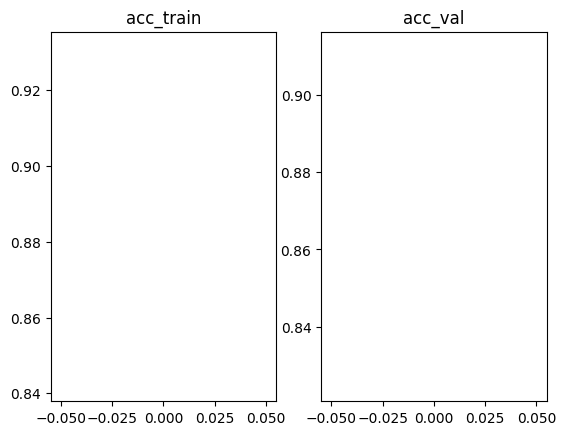

epoch 0 had loss 0.43116527795791626 and acc 0.8866589397913743


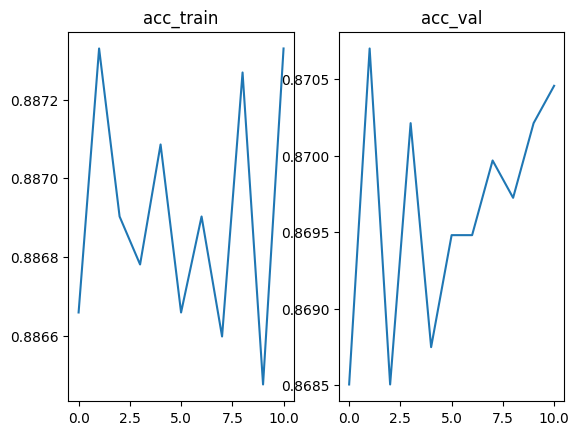

epoch 10 had loss 0.4307115972042084 and acc 0.8873299579088635


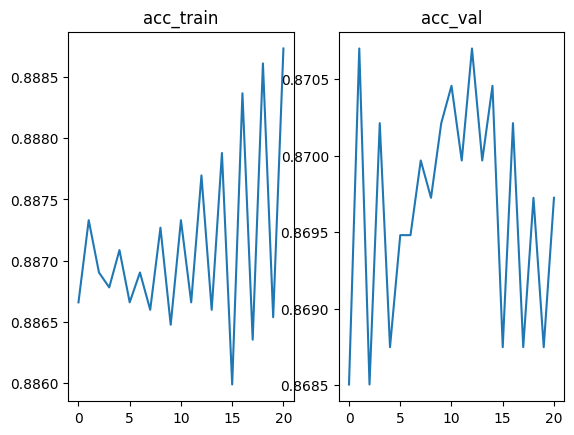

epoch 20 had loss 0.4318736791610718 and acc 0.8887329957908864


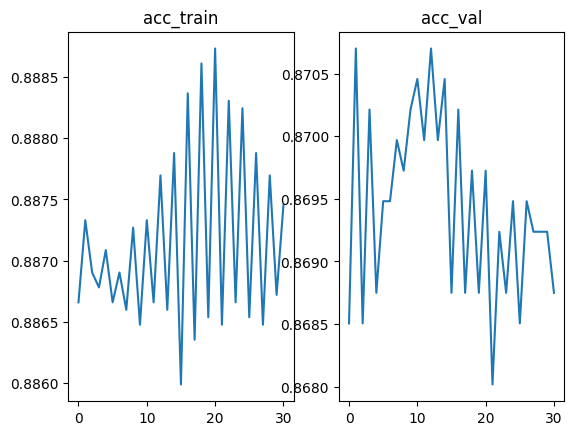

epoch 30 had loss 0.43062809109687805 and acc 0.8874519612029524


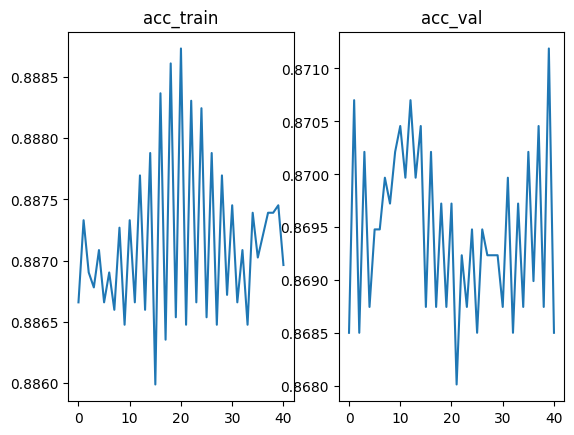

epoch 40 had loss 0.4310007393360138 and acc 0.8869639480265967


KeyboardInterrupt: 

In [ ]:
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

epochs = 2100 # кол-во циклов/шагов тренировки
losses = [None]*epochs
accs = [None]*epochs
vals = [None]*epochs

for i in range(epochs):
    # делаем прогноз
    y_pred = model.forward(x_train)
    # мерим "ошибку"
    loss = criterion(y_pred, y_train)
    losses[i]=loss.detach().numpy()
    acc = accuracy_score(y_train, y_pred.argmax(dim=1))
    accs[i] = acc
    val = validate(model, x_test, y_test)
    vals[i] = val

    figure, axis = plt.subplots(1, 2)
    axis[0].plot(range(epochs), accs)
    axis[0].set_title("acc_train")

    axis[1].plot(range(epochs), vals)
    axis[1].set_title("acc_val")

    plt.show()

	# каждые 10 циклов выводим ошибку
    if i % 10 == 0:
        print(f"epoch {i} had loss {loss} and acc {acc}")

	# переходим к следующему шагу тренировки
    optimizer.zero_grad()
    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=4.0)
    loss.backward()
    optimizer.step()

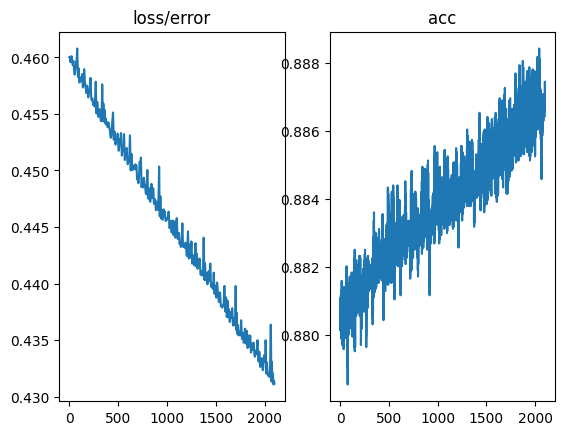

1.)  8 	 8
2.)  6 	 6
3.)  23 	 23
4.)  5 	 5
5.)  21 	 21
6.)  7 	 7
7.)  24 	 26
8.)  0 	 0
9.)  11 	 11
10.)  4 	 7
11.)  12 	 12
12.)  16 	 16
13.)  13 	 13
14.)  11 	 11
15.)  1 	 1
16.)  21 	 21
17.)  28 	 13
18.)  24 	 26
19.)  5 	 5
20.)  23 	 23
21.)  1 	 1
22.)  25 	 25
23.)  3 	 3
24.)  28 	 28
25.)  5 	 5
26.)  16 	 16
27.)  22 	 22
28.)  6 	 6
29.)  22 	 3
30.)  14 	 14
31.)  21 	 21
32.)  23 	 23
33.)  26 	 24
34.)  27 	 27
35.)  25 	 25
36.)  10 	 10
37.)  13 	 13
38.)  23 	 23
39.)  14 	 14
40.)  3 	 3
41.)  19 	 19
42.)  19 	 19
43.)  2 	 2
44.)  5 	 5
45.)  7 	 23
46.)  16 	 16
47.)  25 	 2
48.)  23 	 23
49.)  5 	 5
50.)  5 	 5
51.)  20 	 20
52.)  7 	 7
53.)  15 	 8
54.)  23 	 23
55.)  17 	 20
56.)  20 	 20
57.)  23 	 23
58.)  29 	 4
59.)  7 	 7
60.)  5 	 5
61.)  12 	 12
62.)  5 	 5
63.)  16 	 16
64.)  4 	 4
65.)  1 	 1
66.)  7 	 7
67.)  23 	 23
68.)  20 	 20
69.)  12 	 12
70.)  13 	 13
71.)  10 	 10
72.)  4 	 4
73.)  6 	 6
74.)  27 	 27
75.)  22 	 22
76.)  12 	 12
77

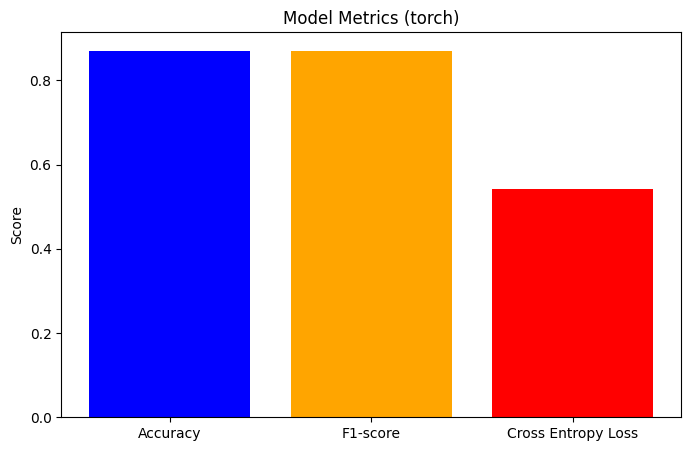

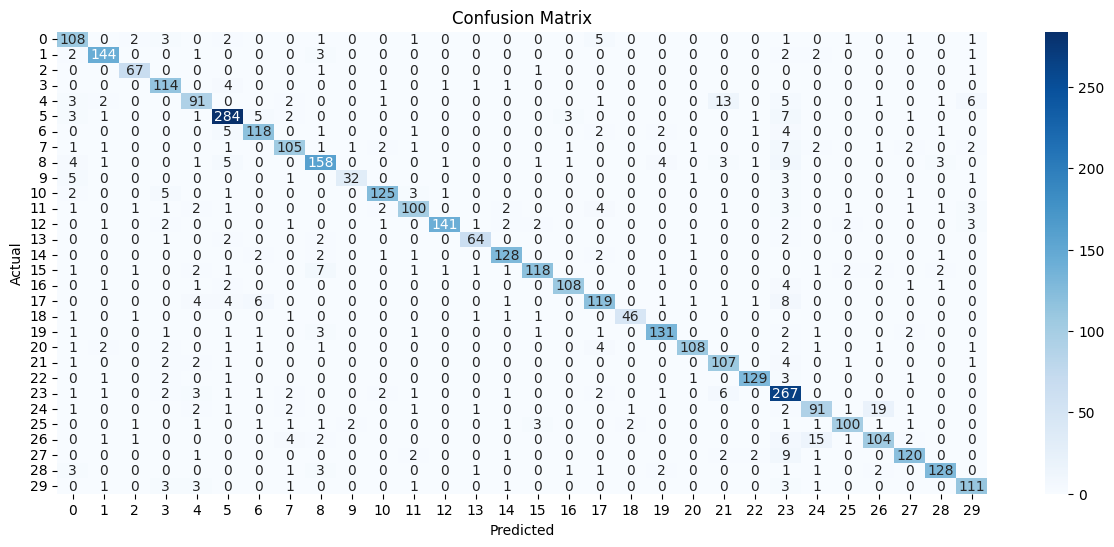

Precision: 0.8799
Recall: 0.8648
F1 Score: 0.8709


In [ ]:
import matplotlib.pyplot as plt

figure, axis = plt.subplots(1, 2)
axis[0].plot(range(epochs), losses)
axis[0].set_title("loss/error")

axis[1].plot(range(epochs), accs)
axis[1].set_title("acc")

plt.show()



correct = 0
with no_grad():
  for i, data in enumerate(x_test):
    y_val = model.forward(data)

    print(f'{i+1}.)  {y_test[i]} \t {y_val.argmax().item()}')

    # Correct or not
    if y_val.argmax().item() == y_test[i]:
      correct +=1

print(f'We got {correct} correct!')
print(f"Acc: {correct / len(x_test)}")



import torch
import matplotlib.pyplot as plt
from ignite.metrics import Accuracy
from ignite.engine import *
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, f1_score, log_loss, roc_auc_score, roc_curve
import seaborn as sns

def eval_step(engine, batch):
    return batch

default_evaluator = Engine(eval_step)

y_pred = model.forward(x_test)
acc = accuracy_score(y_test, y_pred.argmax(dim=1))
f1 = f1_score(y_test, y_pred.argmax(dim=1), average='macro')
cross_entr = log_loss(y_test, F.softmax(y_pred, dim=1).detach().numpy())

# Визуализация метрик
metrics_names = ['Accuracy', 'F1-score', 'Cross Entropy Loss']
metrics_values = [acc, f1, cross_entr]

plt.figure(figsize=(8, 5))
plt.bar(metrics_names, metrics_values, color=['blue', 'orange', 'red'])
plt.ylabel('Score')
plt.title('Model Metrics (torch)')
plt.show()




cm = confusion_matrix(y_test, y_pred.argmax(dim=1))
plt.figure(figsize = (15, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()




precision = precision_score(y_test, y_pred.argmax(dim=1), average='macro')
recall = recall_score(y_test, y_pred.argmax(dim=1), average='macro')
f1 = f1_score(y_test, y_pred.argmax(dim=1), average='macro')

print(f'Precision: {precision:.4f}')
print(f'Recall: {recall:.4f}')
print(f'F1 Score: {f1:.4f}')

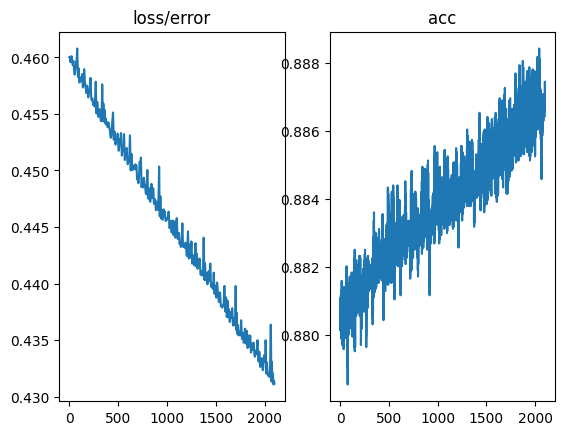

1.)  8 	 8
2.)  6 	 6
3.)  23 	 23
4.)  5 	 5
5.)  21 	 21
6.)  7 	 7
7.)  24 	 26
8.)  0 	 0
9.)  11 	 11
10.)  4 	 7
11.)  12 	 12
12.)  16 	 16
13.)  13 	 13
14.)  11 	 11
15.)  1 	 1
16.)  21 	 21
17.)  28 	 13
18.)  24 	 26
19.)  5 	 5
20.)  23 	 23
21.)  1 	 1
22.)  25 	 25
23.)  3 	 3
24.)  28 	 28
25.)  5 	 5
26.)  16 	 16
27.)  22 	 22
28.)  6 	 6
29.)  22 	 3
30.)  14 	 14
31.)  21 	 21
32.)  23 	 23
33.)  26 	 24
34.)  27 	 27
35.)  25 	 25
36.)  10 	 10
37.)  13 	 13
38.)  23 	 23
39.)  14 	 14
40.)  3 	 3
41.)  19 	 19
42.)  19 	 19
43.)  2 	 2
44.)  5 	 5
45.)  7 	 23
46.)  16 	 16
47.)  25 	 2
48.)  23 	 23
49.)  5 	 5
50.)  5 	 5
51.)  20 	 20
52.)  7 	 7
53.)  15 	 8
54.)  23 	 23
55.)  17 	 20
56.)  20 	 20
57.)  23 	 23
58.)  29 	 4
59.)  7 	 7
60.)  5 	 5
61.)  12 	 12
62.)  5 	 5
63.)  16 	 16
64.)  4 	 4
65.)  1 	 1
66.)  7 	 7
67.)  23 	 23
68.)  20 	 20
69.)  12 	 12
70.)  13 	 13
71.)  10 	 10
72.)  4 	 4
73.)  6 	 6
74.)  27 	 27
75.)  22 	 22
76.)  12 	 12
77

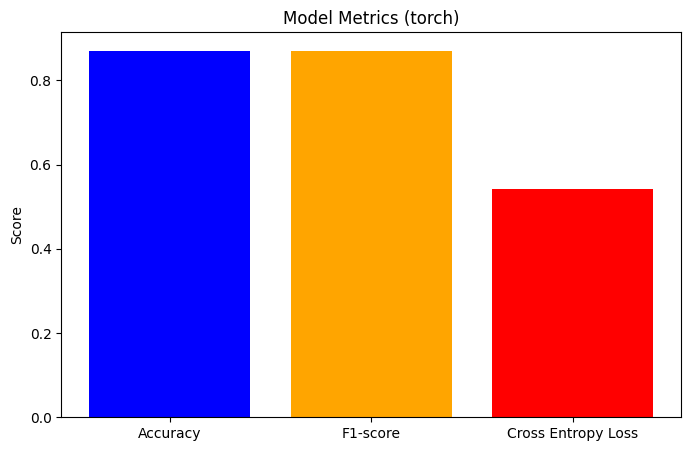

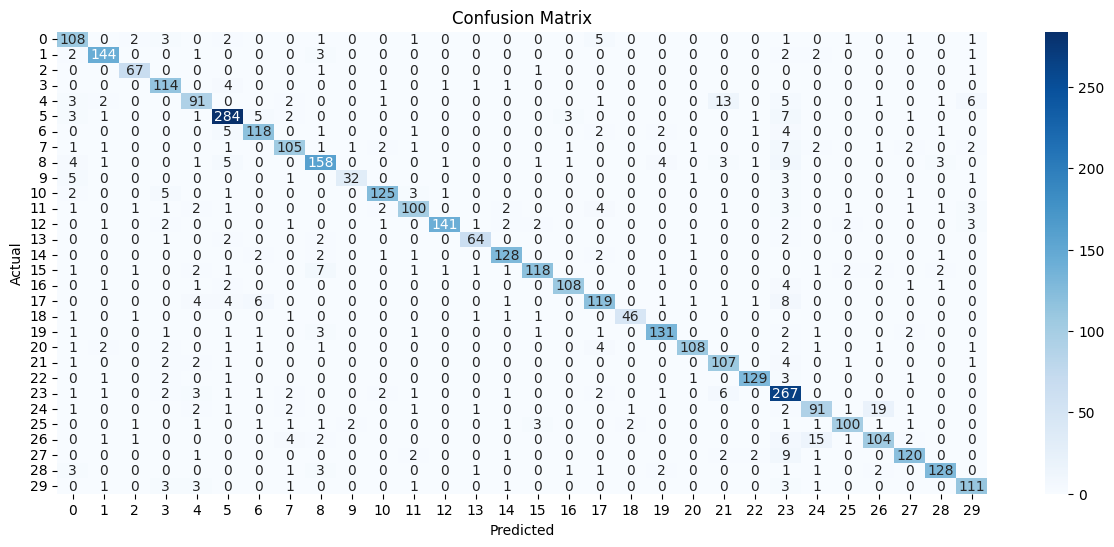

Precision: 0.8799
Recall: 0.8648
F1 Score: 0.8709


In [154]:
import matplotlib.pyplot as plt

figure, axis = plt.subplots(1, 2)
axis[0].plot(range(epochs), losses)
axis[0].set_title("loss/error")

axis[1].plot(range(epochs), accs)
axis[1].set_title("acc")

plt.show()



correct = 0
with no_grad():
  for i, data in enumerate(x_test):
    y_val = model.forward(data)

    print(f'{i+1}.)  {y_test[i]} \t {y_val.argmax().item()}')

    # Correct or not
    if y_val.argmax().item() == y_test[i]:
      correct +=1

print(f'We got {correct} correct!')
print(f"Acc: {correct / len(x_test)}")



import torch
import matplotlib.pyplot as plt
from ignite.metrics import Accuracy
from ignite.engine import *
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, f1_score, log_loss, roc_auc_score, roc_curve
import seaborn as sns

def eval_step(engine, batch):
    return batch

default_evaluator = Engine(eval_step)

y_pred = model.forward(x_test)
acc = accuracy_score(y_test, y_pred.argmax(dim=1))
f1 = f1_score(y_test, y_pred.argmax(dim=1), average='macro')
cross_entr = log_loss(y_test, F.softmax(y_pred, dim=1).detach().numpy())

# Визуализация метрик
metrics_names = ['Accuracy', 'F1-score', 'Cross Entropy Loss']
metrics_values = [acc, f1, cross_entr]

plt.figure(figsize=(8, 5))
plt.bar(metrics_names, metrics_values, color=['blue', 'orange', 'red'])
plt.ylabel('Score')
plt.title('Model Metrics (torch)')
plt.show()




cm = confusion_matrix(y_test, y_pred.argmax(dim=1))
plt.figure(figsize = (15, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()




precision = precision_score(y_test, y_pred.argmax(dim=1), average='macro')
recall = recall_score(y_test, y_pred.argmax(dim=1), average='macro')
f1 = f1_score(y_test, y_pred.argmax(dim=1), average='macro')

print(f'Precision: {precision:.4f}')
print(f'Recall: {recall:.4f}')
print(f'F1 Score: {f1:.4f}')

In [115]:
from torch import no_grad

with no_grad():
  y_eval = model.forward(x_test)
  loss = criterion(y_eval, y_test)

In [116]:
loss

tensor(1.0466)

In [99]:
correct = 0
with no_grad():
  for i, data in enumerate(x_test):
    y_val = model.forward(data)

    print(f'{i+1}.)  {y_test[i]} \t {y_val.argmax().item()}')

    # Correct or not
    if y_val.argmax().item() == y_test[i]:
      correct +=1

print(f'We got {correct} correct!')
print(f"Acc: {correct / len(x_test)}")

1.)  26 	 8
2.)  10 	 14
3.)  19 	 19
4.)  12 	 12
5.)  23 	 23
6.)  17 	 17
7.)  5 	 0
8.)  26 	 7
9.)  26 	 26
10.)  23 	 23
11.)  12 	 12
12.)  17 	 17
13.)  4 	 4
14.)  17 	 17
15.)  23 	 23
16.)  4 	 4
17.)  28 	 28
18.)  12 	 12
19.)  21 	 21
20.)  13 	 13
21.)  21 	 4
22.)  17 	 17
23.)  28 	 28
24.)  19 	 19
25.)  15 	 15
26.)  4 	 23
27.)  29 	 29
28.)  12 	 23
29.)  19 	 19
30.)  25 	 25
31.)  7 	 7
32.)  1 	 1
33.)  10 	 10
34.)  5 	 5
35.)  29 	 4
36.)  8 	 8
37.)  26 	 26
38.)  17 	 5
39.)  0 	 0
40.)  5 	 5
41.)  19 	 19
42.)  15 	 8
43.)  27 	 27
44.)  29 	 29
45.)  6 	 6
46.)  23 	 23
47.)  14 	 14
48.)  1 	 1
49.)  8 	 8
50.)  24 	 24
51.)  28 	 28
52.)  20 	 20
53.)  22 	 22
54.)  23 	 23
55.)  12 	 12
56.)  15 	 15
57.)  5 	 5
58.)  10 	 10
59.)  23 	 23
60.)  5 	 1
61.)  9 	 8
62.)  16 	 16
63.)  5 	 4
64.)  28 	 28
65.)  28 	 29
66.)  4 	 24
67.)  6 	 6
68.)  2 	 2
69.)  19 	 11
70.)  15 	 15
71.)  8 	 8
72.)  5 	 23
73.)  26 	 26
74.)  26 	 26
75.)  10 	 10
76.)  

In [20]:
#torch.save(model, "./modelpart1.pt")

In [21]:
import torch

# tosave = torch.load("modelpart1.pt")
# tosave

In [ ]:
from torch.utils.mobile_optimizer import optimize_for_mobile

# Генериреум случайные числа2
X = torch.distributions.uniform.Uniform(-10000, \
	10000).sample((30, 42))

# Делаем модель оптимизированной
traced_script_module = torch.jit.trace(model, X)
traced_script_module_optimized = optimize_for_mobile(\
	traced_script_module)

# Сохраняем оптимизированную модель
traced_script_module_optimized._save_for_lite_interpreter(\
        "modelultracool4.pt")

### Смотрим на метрики исходной модели

In [22]:
import torch
model = torch.load("modelultracool4.pt", weights_only=False)

c:\Program Files\Python313\Lib\site-packages\torch\serialization.py:1493: UserWarning: 'torch.load' received a zip file that looks like a TorchScript archive dispatching to 'torch.jit.load' (call 'torch.jit.load' directly to silence this warning)
  warnings.warn(


In [23]:
model.forward(x_test[1])

tensor([  6.7498, -25.6998,  10.8784, -13.0665, -14.2818,  -8.0203, -10.4256,
          1.3351,  15.0372, -10.8126,  12.8832, -25.8717,   2.8082,  -3.7867,
        -20.0115,  21.4963,  -3.7462, -24.2908,   5.8009,   3.6010, -25.6257,
        -20.3124, -28.8766,  -6.0823,  -6.6356,   9.6464,   0.4160,  -3.9566,
          2.2679, -14.9939])

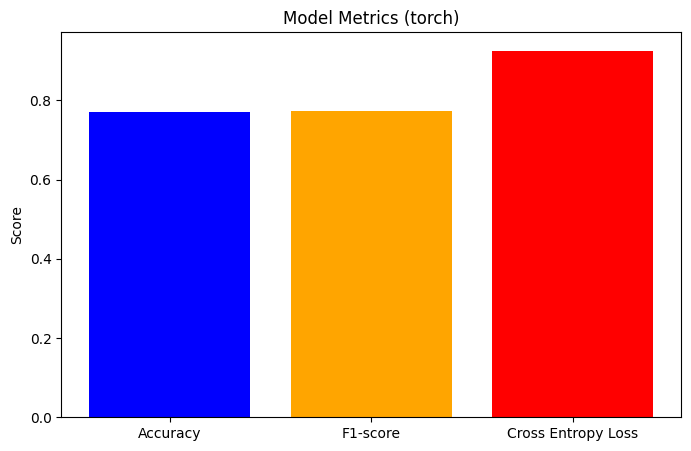

In [87]:
import torch
import matplotlib.pyplot as plt
from ignite.metrics import Accuracy
from ignite.engine import *
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, f1_score, log_loss, roc_auc_score, roc_curve
import seaborn as sns

def eval_step(engine, batch):
    return batch

default_evaluator = Engine(eval_step)

y_pred = model.forward(x_test)
acc = accuracy_score(y_test, y_pred.argmax(dim=1))
f1 = f1_score(y_test, y_pred.argmax(dim=1), average='macro')
cross_entr = log_loss(y_test, F.softmax(y_pred, dim=1).detach().numpy())

# Визуализация метрик
metrics_names = ['Accuracy', 'F1-score', 'Cross Entropy Loss']
metrics_values = [acc, f1, cross_entr]

plt.figure(figsize=(8, 5))
plt.bar(metrics_names, metrics_values, color=['blue', 'orange', 'red'])
plt.ylabel('Score')
plt.title('Model Metrics (torch)')
plt.show()

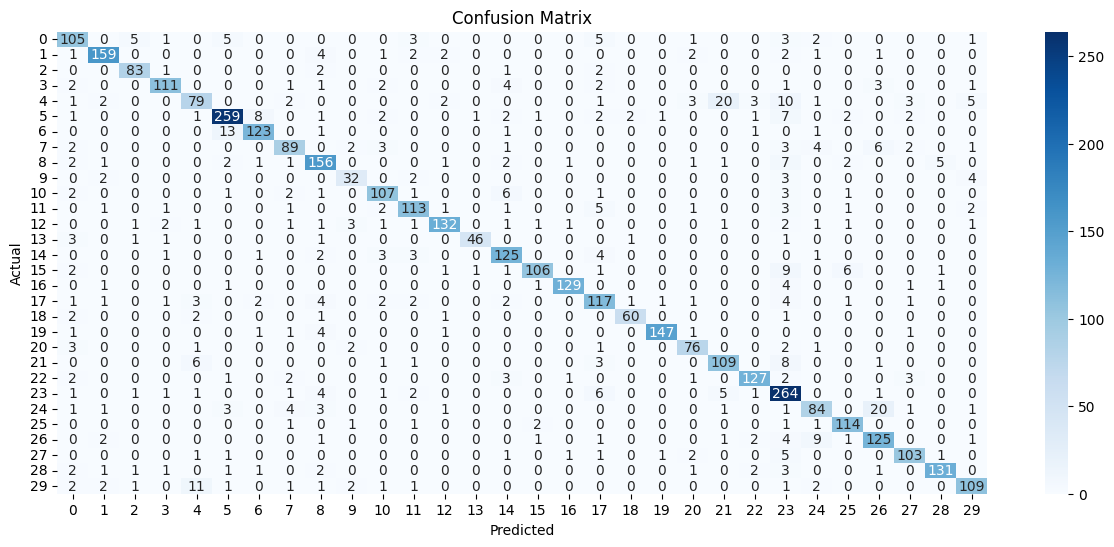

In [65]:
cm = confusion_matrix(y_test, y_pred.argmax(dim=1))
plt.figure(figsize = (15, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [66]:
y_pred.argmax(dim=1).shape

torch.Size([4099])

In [67]:
y_test.shape

torch.Size([4099])

In [88]:
precision = precision_score(y_test, y_pred.argmax(dim=1), average='macro')
recall = recall_score(y_test, y_pred.argmax(dim=1), average='macro')
f1 = f1_score(y_test, y_pred.argmax(dim=1), average='macro')

print(f'Precision: {precision:.4f}')
print(f'Recall: {recall:.4f}')
print(f'F1 Score: {f1:.4f}')

Precision: 0.7918
Recall: 0.7653
F1 Score: 0.7738


In [118]:
y_pred.argmax().item()

306938

In [96]:
y_test

tensor([14, 16,  5,  ..., 12, 23,  5])